In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#To split data into stratified train and test sets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

#for XGBoost model data format
from sklearn.preprocessing import LabelEncoder 

# Import Model
import xgboost as xgb

#for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import Metrics
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse
from scipy.special import huber
from sklearn.metrics import make_scorer, mean_pinball_loss

import datagen as gen

Loading/Preprocessing Data

In [ ]:
#read in the cleaned data file

df = gen.load_training_data()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5605266 entries, 0 to 5605265
Data columns (total 46 columns):
 #   Column                Dtype  
---  ------                -----  
 0   RECORD_ID             int64  
 1   THCIC_ID              int64  
 2   TYPE_OF_ADMISSION     float64
 3   SOURCE_OF_ADMISSION   str    
 4   PUBLIC_HEALTH_REGION  float64
 5   PAT_STATUS            int64  
 6   SEX_CODE              str    
 7   RACE                  int64  
 8   ETHNICITY             int64  
 9   ADMIT_WEEKDAY         float64
 10  LENGTH_OF_STAY        float64
 11  PAT_AGE               int64  
 12  EMERGENCY_DEPT_FLAG   str    
 13  DIAG_CODES_OA         str    
 14  CODE_1                int64  
 15  CODE_2                int64  
 16  CODE_3                int64  
 17  CODE_4                int64  
 18  CODE_5                int64  
 19  CODE_6                int64  
 20  CODE_7                int64  
 21  CODE_8                int64  
 22  CODE_9                int64  
 23  CODE_10           

In [ ]:
cat_features = ['TYPE_OF_ADMISSION',
    'SEX_CODE',
    'RACE',
    'ETHNICITY',
    'ADMIT_WEEKDAY',
    'EMERGENCY_DEPT_FLAG',
    'CODE_1',
    'CODE_2',
    'CODE_3',
    'CODE_4',
    'CODE_5',
    'CODE_6',
    'CODE_7',
    'CODE_8',
    'CODE_9',
    'CODE_10',
    'CODE_11',
    'CODE_12',
    'CODE_13',
    'CODE_14',
    'CODE_15',
    'CODE_16',
    'CODE_17',
    'CODE_18',
    'CODE_19',
    'CODE_20',
    'CODE_21',
    'PAT_RURAL',
    'PROVIDER_RURAL',
    'QUARTER']
cat_features

['TYPE_OF_ADMISSION',
 'SEX_CODE',
 'RACE',
 'ETHNICITY',
 'ADMIT_WEEKDAY',
 'EMERGENCY_DEPT_FLAG',
 'CODE_1',
 'CODE_2',
 'CODE_3',
 'CODE_4',
 'CODE_5',
 'CODE_6',
 'CODE_7',
 'CODE_8',
 'CODE_9',
 'CODE_10',
 'CODE_11',
 'CODE_12',
 'CODE_13',
 'CODE_14',
 'CODE_15',
 'CODE_16',
 'CODE_17',
 'CODE_18',
 'CODE_19',
 'CODE_20',
 'CODE_21',
 'CODE_22',
 'PAT_RURAL',
 'PROVIDER_RURAL',
 'QUARTER']

In [5]:
#Define categorical features, and put into a data type that works with XGBoost
df[cat_features] = (
    df[cat_features]
    .fillna("Missing")
    .astype('category')
)

In [6]:
#Make list of all features to be used in the model, including categorical features and numerical features
features = cat_features.copy()
features.extend(['PAT_AGE','PAT_LATITUDE','PAT_LONGITUDE','PROVIDER_LATITUDE','PROVIDER_LONGITUDE','NUM_CODES','PAT2PROV_DISTANCE'])

features

['TYPE_OF_ADMISSION',
 'SEX_CODE',
 'RACE',
 'ETHNICITY',
 'ADMIT_WEEKDAY',
 'EMERGENCY_DEPT_FLAG',
 'CODE_1',
 'CODE_2',
 'CODE_3',
 'CODE_4',
 'CODE_5',
 'CODE_6',
 'CODE_7',
 'CODE_8',
 'CODE_9',
 'CODE_10',
 'CODE_11',
 'CODE_12',
 'CODE_13',
 'CODE_14',
 'CODE_15',
 'CODE_16',
 'CODE_17',
 'CODE_18',
 'CODE_19',
 'CODE_20',
 'CODE_21',
 'CODE_22',
 'PAT_RURAL',
 'PROVIDER_RURAL',
 'QUARTER',
 'PAT_AGE',
 'PAT_LATITUDE',
 'PAT_LONGITUDE',
 'PROVIDER_LATITUDE',
 'PROVIDER_LONGITUDE',
 'NUM_CODES',
 'PAT2PROV_DISTANCE']

Hyperparameter Tuning

In [7]:
#Split data into a small subset for hyperparameter tuning
X_hyp_train, X_hyp_test, y_hyp_train, y_hyp_test = train_test_split(df[features],df.LENGTH_OF_STAY,
                                                    shuffle = True,
                                                    random_state = 1990,
                                                    stratify = df['STRATA'],
                                                   test_size = .975)

In [8]:
#Calculate percentage of data with a stay length less than or equal to 30 days
quantile = df.loc[df.LENGTH_OF_STAY.astype(int) <= 30].shape[0]/df.shape[0]
quantile

0.987531903035467

In [32]:
#Hyperparameter Tuning with RMSE
#Create validation set from the training data for hyperparameter tuning; required for XGBoost early stopping
X_hyp_tr, X_hyp_val, y_hyp_tr, y_hyp_val = train_test_split(X_hyp_train, y_hyp_train, test_size=0.2, random_state=42)

#encode target variable for XGBoost
le = LabelEncoder()
y_hyp_tr_encoded = le.fit_transform(y_hyp_tr)
y_hyp_val_encoded = le.fit_transform(y_hyp_val)

#hyperparameters that we want to tune/scan over
param_grid = {
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.05, 0.075, 0.1],
    "min_child_weight": [1, 3, 5],
    "max_cat_threshold": [16, 32, 64],
}

    
    # Instantiate Model for RMSE
model = xgb.XGBRegressor(
        n_estimators=1000,
        objective="reg:squarederror",
        eval_metric = "rmse",
        random_state=42,
        early_stopping_rounds=400,
        gamma=0,
        enable_categorical=True
    )

#Run the model over the hyperparameter grid to find the best combination of hyperparameters
grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = "neg_root_mean_squared_error",
        cv = 3,  
        verbose = 2,
        n_jobs = -1
    )

grid_search.fit(X_hyp_train, y_hyp_train, eval_set=[(X_hyp_val, y_hyp_val_encoded)],verbose=500)

rmse_results = pd.DataFrame(grid_search.cv_results_)

rmse_results.to_csv("rmse_grid_search_results.csv", index=False)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[0]	validation_0-rmse:7.59813
[0]	validation_0-rmse:7.56596
[0]	validation_0-rmse:7.58564
[0]	validation_0-rmse:7.61974
[0]	validation_0-rmse:7.58256
[0]	validation_0-rmse:7.58564
[0]	validation_0-rmse:7.61974
[0]	validation_0-rmse:7.58564
[0]	validation_0-rmse:7.59789
[0]	validation_0-rmse:7.57085
[0]	validation_0-rmse:7.61974
[0]	validation_0-rmse:7.59789
[489]	validation_0-rmse:9.06301
[CV] END learning_rate=0.05, max_cat_threshold=16, max_depth=4, min_child_weight=1; total time=  20.9s
[409]	validation_0-rmse:10.05123
[CV] END learning_rate=0.05, max_cat_threshold=16, max_depth=5, min_child_weight=1; total time=  21.0s
[0]	validation_0-rmse:7.56596
[0]	validation_0-rmse:7.58347
[488]	validation_0-rmse:8.33891
[CV] END learning_rate=0.05, max_cat_threshold=16, max_depth=4, min_child_weight=3; total time=  22.2s
[0]	validation_0-rmse:7.57084
[500]	validation_0-rmse:7.84166
[523]	validation_0-rmse:7.89121
[CV] END learning

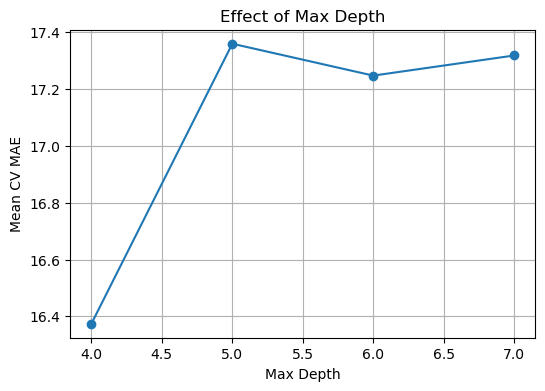

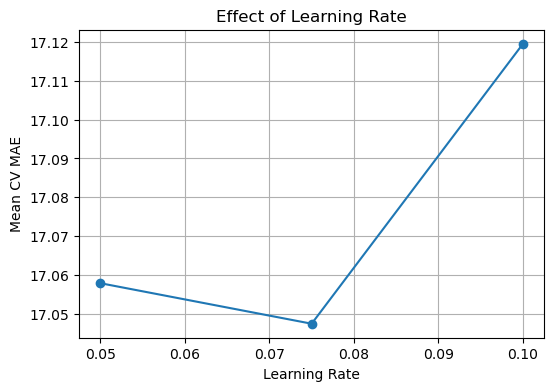

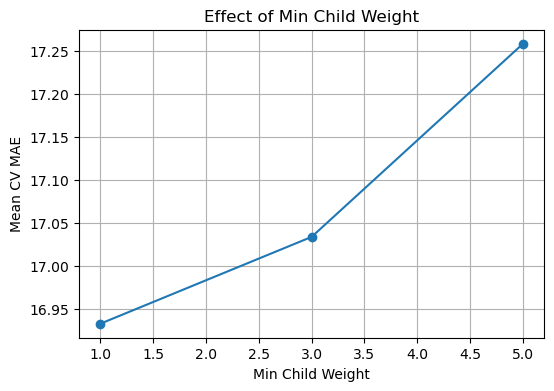

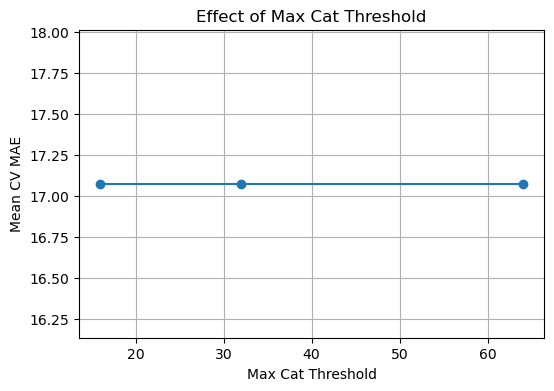

In [35]:
# Visuals for Hyperparameter Tuning on RMSE model

parameters = [
    "max_depth",
    "learning_rate",
    "min_child_weight",
    "max_cat_threshold"
]

for param in parameters:
    scores = (
        rmse_results.groupby(f"param_{param}")["mean_test_score"]
        .mean()
    )

    plt.figure(figsize=(6,4))
    plt.plot(scores.index, -scores.values, marker="o")   # Negate to show MAE instead of -MAE
    plt.xlabel(param.replace("_", " ").title())
    plt.ylabel("Mean CV MAE")
    plt.title(f"Effect of {param.replace('_', ' ').title()}")
    plt.grid(True)
    plt.show()

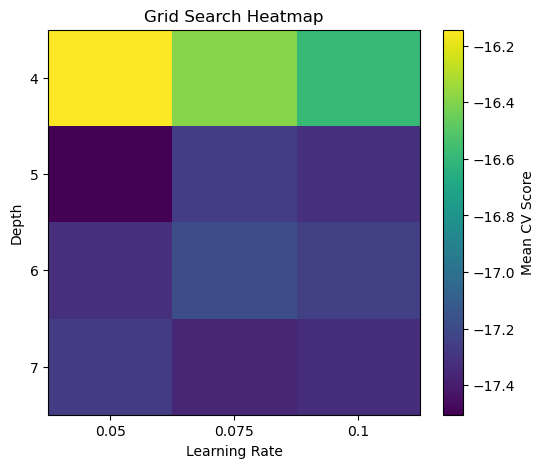

In [36]:
# Heatmap for Hyperparameter Tuning for RMSE model (Depth vs Learning Rate)
pivot = rmse_results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_learning_rate"
)

plt.figure(figsize=(6,5))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Mean CV Score")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Learning Rate")
plt.ylabel("Depth")
plt.title("Grid Search Heatmap")
plt.show()

In [12]:
#Hyperparameter Tuning with MAE
#Create validation set from the training data for hyperparameter tuning; required for XGBoost early stopping
X_hyp_tr, X_hyp_val, y_hyp_tr, y_hyp_val = train_test_split(X_hyp_train, y_hyp_train, test_size=0.2, random_state=42)

#encode target variable for XGBoost
le = LabelEncoder()
y_hyp_tr_encoded = le.fit_transform(y_hyp_tr)
y_hyp_val_encoded = le.fit_transform(y_hyp_val)

#hyperparameters that we want to tune/scan over
param_grid = {
    "max_depth": [5, 6, 7],
    "learning_rate": [0.03, 0.05, .075],
    "min_child_weight": [1, 3],
    "max_cat_threshold": [16, 32],
}

    
    # Instantiate Model for MAE
model = xgb.XGBRegressor(
        n_estimators=1000,
        objective="reg:absoluteerror",
        eval_metric = "mae",
        random_state=42,
        early_stopping_rounds=400,
        gamma=0,
        enable_categorical=True
    )

#Run the model over the hyperparameter grid to find the best combination of hyperparameters
grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = "neg_mean_absolute_error",
        cv = 3,  
        verbose = 2,
        n_jobs = -1
    )

grid_search.fit(X_hyp_train, y_hyp_train, eval_set=[(X_hyp_val, y_hyp_val_encoded)], verbose = 500)



Fitting 3 folds for each of 36 candidates, totalling 108 fits
[0]	validation_0-mae:3.40906
[0]	validation_0-mae:3.40877
[0]	validation_0-mae:3.40664
[0]	validation_0-mae:3.40877
[0]	validation_0-mae:3.40917
[0]	validation_0-mae:3.40727
[0]	validation_0-mae:3.40548
[0]	validation_0-mae:3.40664
[0]	validation_0-mae:3.40549
[0]	validation_0-mae:3.40695
[0]	validation_0-mae:3.40701
[0]	validation_0-mae:3.40728
[500]	validation_0-mae:2.93977
[500]	validation_0-mae:2.94007
[500]	validation_0-mae:2.93055
[500]	validation_0-mae:2.89162
[500]	validation_0-mae:2.89511
[500]	validation_0-mae:2.91302
[500]	validation_0-mae:2.91199
[500]	validation_0-mae:2.92764
[500]	validation_0-mae:2.92483
[500]	validation_0-mae:2.89064
[500]	validation_0-mae:2.92497
[500]	validation_0-mae:2.89858
[999]	validation_0-mae:2.92152
[999]	validation_0-mae:2.88844
[CV] END learning_rate=0.03, max_cat_threshold=16, max_depth=5, min_child_weight=3; total time= 1.7min
[999]	validation_0-mae:2.89708
[0]	validation_0-mae:3

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...teerror', ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_cat_threshold': [16, 32], 'max_depth': [5, 6, ...], 'min_child_weight': [1, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [15]:
#Hyperparameter Tuning with Quantile
#Create validation set from the training data for hyperparameter tuning; required for XGBoost early stopping
X_hyp_tr, X_hyp_val, y_hyp_tr, y_hyp_val = train_test_split(X_hyp_train, y_hyp_train, test_size=0.2, random_state=42)

#encode target variable for XGBoost
le = LabelEncoder()
y_hyp_tr_encoded = le.fit_transform(y_hyp_tr)
y_hyp_val_encoded = le.fit_transform(y_hyp_val)

#hyperparameters that we want to tune/scan over
param_grid = {
    "max_depth": [4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05],
    "min_child_weight": [1, 3, 5],
    "max_cat_threshold": [16, 32],
}

    
    # Instantiate Model for quantile
model = xgb.XGBRegressor(
        n_estimators=1000,
        objective="reg:quantileerror",
        quantile_alpha=quantile,
        #eval_metric = "",
        random_state=42,
        early_stopping_rounds=400,
        gamma=0,
        enable_categorical=True
    )

#Run the model over the hyperparameter grid to find the best combination of hyperparameters
grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring=make_scorer(
            mean_pinball_loss,
            alpha=0.987531903035467,
            greater_is_better=False
            ),        
        cv = 3,  
        verbose = 2,
        n_jobs = -1
    )

grid_search.fit(X_hyp_train, y_hyp_train, eval_set=[(X_hyp_val, y_hyp_val_encoded)], verbose = 500)



Fitting 3 folds for each of 54 candidates, totalling 162 fits
[0]	validation_0-quantile:0.60558
[0]	validation_0-quantile:0.60584
[0]	validation_0-quantile:0.60538
[0]	validation_0-quantile:0.60680
[0]	validation_0-quantile:0.60680
[0]	validation_0-quantile:0.60585
[0]	validation_0-quantile:0.60680
[0]	validation_0-quantile:0.60532
[0]	validation_0-quantile:0.60387
[0]	validation_0-quantile:0.60426
[0]	validation_0-quantile:0.60538
[0]	validation_0-quantile:0.60585
[500]	validation_0-quantile:0.34328
[500]	validation_0-quantile:0.34924
[500]	validation_0-quantile:0.34561
[500]	validation_0-quantile:0.34644
[500]	validation_0-quantile:0.34256
[500]	validation_0-quantile:0.33950
[500]	validation_0-quantile:0.33897
[500]	validation_0-quantile:0.34185
[500]	validation_0-quantile:0.34380
[500]	validation_0-quantile:0.32760
[500]	validation_0-quantile:0.34527
[500]	validation_0-quantile:0.34006
[999]	validation_0-quantile:0.34183
[CV] END learning_rate=0.01, max_cat_threshold=16, max_depth=4

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...leerror', ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.03, ...], 'max_cat_threshold': [16, 32], 'max_depth': [4, 5, ...], 'min_child_weight': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...7531903035467)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [18]:
#Hyperparameter Tuning with Huber
#Create validation set from the training data for hyperparameter tuning; required for XGBoost early stopping
X_hyp_tr, X_hyp_val, y_hyp_tr, y_hyp_val = train_test_split(X_hyp_train, y_hyp_train, test_size=0.2, random_state=42)

#encode target variable for XGBoost
le = LabelEncoder()
y_hyp_tr_encoded = le.fit_transform(y_hyp_tr)
y_hyp_val_encoded = le.fit_transform(y_hyp_val)

#hyperparameters that we want to tune/scan over
param_grid = {
    "max_depth": [6, 7],
    "learning_rate": [0.01, 0.03, 0.05],
    "min_child_weight": [1, 3],
    "max_cat_threshold": [16, 32],
}

#Function to define huber loss for use in GridSearchCV scoring
def huber_loss(y_true, y_pred, delta=2.0):
    error = y_true.astype(int) - y_pred.astype(int)
    is_small = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small, squared, linear))

huber_scorer = make_scorer(
    huber_loss,
    delta=2.0,
    greater_is_better=False)

# Instantiate Model for Huber
model = xgb.XGBRegressor(
        n_estimators=1000,
        objective="reg:pseudohubererror",
        eval_metric = "mphe",
        huber_slope = 2,
        random_state=42,
        early_stopping_rounds=400,
        gamma=0,
        enable_categorical=True
    )

#Run the model over the hyperparameter grid to find the best combination of hyperparameters
grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = huber_scorer,
        cv = 3,  
        verbose = 2,
        n_jobs = -1
    )

grid_search.fit(X_hyp_train, y_hyp_train, eval_set=[(X_hyp_val, y_hyp_val_encoded)], verbose = 500)



Fitting 3 folds for each of 24 candidates, totalling 72 fits
[0]	validation_0-mphe:7.01574
[0]	validation_0-mphe:7.03611
[0]	validation_0-mphe:7.01265
[0]	validation_0-mphe:7.01629
[0]	validation_0-mphe:7.01585
[0]	validation_0-mphe:7.00918
[0]	validation_0-mphe:7.03894
[0]	validation_0-mphe:7.01245
[0]	validation_0-mphe:7.01644
[0]	validation_0-mphe:7.03233
[0]	validation_0-mphe:7.03525
[0]	validation_0-mphe:7.01245
[500]	validation_0-mphe:3.87063
[500]	validation_0-mphe:3.87772
[500]	validation_0-mphe:3.81034
[500]	validation_0-mphe:3.86764
[500]	validation_0-mphe:3.88998
[500]	validation_0-mphe:3.88255
[500]	validation_0-mphe:3.78682
[500]	validation_0-mphe:3.82621
[500]	validation_0-mphe:3.89084
[500]	validation_0-mphe:3.78911
[500]	validation_0-mphe:3.78287
[500]	validation_0-mphe:3.82901
[999]	validation_0-mphe:3.76883
[CV] END learning_rate=0.01, max_cat_threshold=16, max_depth=6, min_child_weight=1; total time= 1.1min
[999]	validation_0-mphe:3.71758
[0]	validation_0-mphe:7.0162

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.03, ...], 'max_cat_threshold': [16, 32], 'max_depth': [6, 7], 'min_child_weight': [1, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(h...t', delta=2.0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

Running Model (with tuned hyperparameters)

In [19]:
#Split into training and test sets for final model evaluation
X_train, X_test, y_train, y_test = train_test_split(df[features],df.LENGTH_OF_STAY, shuffle = True, random_state = 2222, stratify = df['STRATA'], test_size = .2)

In [20]:
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

In [21]:
#creating a variable for use in stratified k-fold
strata_train = df.loc[X_train.index, 'STRATA']

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2222
)

In [22]:
# Run the models for each metric on the train set, recording each metric.
# Dictionary defining different metrics and tuned hyperparameters [max_depth, learning_rate, min_child_weight, max_cat_threshold]
metrics = {"rmse" : [4,0.075,3],
           "mae": [7,0.03,1],
           "mphe": [7,0.03,1],
           "quantile": [5,0.03,3]}

#creating a framework to store the results of each model
scores = pd.DataFrame(
    0.0,
    index=["RMSE", "MAE", "Huber", "Quantile"],
    columns=["RMSE", "MAE", "Huber", "Quantile"]
)

row_names = {
    "rmse": "RMSE",
    "mae": "MAE",
    "mphe": "Huber",
    "quantile": "Quantile"
}

scores_test = pd.DataFrame(
    0.0,
    index=["RMSE", "MAE", "Huber", "Quantile"],
    columns=["RMSE", "MAE", "Huber", "Quantile"]
)

row_names = {
    "rmse": "RMSE",
    "mae": "MAE",
    "mphe": "Huber",
    "quantile": "Quantile"
}

for metric,params in metrics.items():
    fold_rmse = []
    fold_mae = []
    fold_huber = []
    fold_quantile = []

    fold_rmse_test = []
    fold_mae_test = []
    fold_huber_test = []
    fold_quantile_test = []
    # Fit the model for each fold
    
    print(f"\nTraining {metric} model...")


    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, strata_train)):
        X_tr = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[valid_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        le = LabelEncoder()
        y_tr_encoded = le.fit_transform(y_tr)
        y_val_encoded = le.fit_transform(y_val)


        # Instantiate Model
        model = xgb.XGBRegressor(
            max_depth=params[0], #Tuned Hyperparameter 1
            learning_rate=params[1], #Tuned Hyperparameter 2
            min_child_weight=params[2], #Tuned Hyperparameter 3
            max_cat_threshold=16, #Tuned Hyperparameter 4
            n_estimators=4000,
            eval_metric=metric,
            random_state=42,
            early_stopping_rounds=400,
            enable_categorical=True,
            objective = "reg:squarederror" if metric == "rmse" else (
                "reg:absoluteerror" if metric == "mae" else (
                    "reg:pseudohubererror" if metric == "mphe" else (
                        "reg:quantileerror"
                    )
                )   
            ),
            quantile_alpha=quantile if metric == "quantile" else None,
            huber_slope=2 if metric == "mphe" else None,
        )

        model.fit(X_tr, y_tr_encoded, eval_set=[(X_val, y_val_encoded)], verbose=100)

        # Find predictions and store rmses  
        preds = model.predict(X_val)
    
        rmse_pred = rmse(y_val_encoded,preds)
        mae_pred = mae(y_val_encoded,preds)
        quantile_pred = mean_pinball_loss(
            y_val_encoded,
            preds,
            alpha=0.987531903035467
        )

        huber_pred = huber_loss(y_val_encoded, preds, delta=2.0)

        fold_rmse.append(rmse_pred)
        fold_mae.append(mae_pred)
        fold_huber.append(huber_pred)
        fold_quantile.append(quantile_pred)

        


        preds_test = model.predict(X_test)
    
        rmse_pred_test = rmse(y_test_encoded,preds_test)
        mae_pred_test = mae(y_test_encoded,preds_test)
        quantile_pred_test = mean_pinball_loss(
            y_test_encoded,
            preds_test,
            alpha=0.987531903035467
        )

        huber_pred_test = huber_loss(y_test_encoded, preds_test, delta=2.0)

        fold_rmse_test.append(rmse_pred_test)
        fold_mae_test.append(mae_pred_test)
        fold_huber_test.append(huber_pred_test)
        fold_quantile_test.append(quantile_pred_test)


        print(
        f"{metric} | Fold {fold+1}/{skf.get_n_splits()} | "
        f"RMSE={rmse_pred:.3f}, "
        f"MAE={mae_pred:.3f}, "
        f"Huber={huber_pred:.3f}, "
        f"Quantile={quantile_pred:.5f}"
        )

    row = row_names[metric]
    
    scores.loc[row, "RMSE"] = np.mean(fold_rmse)
    scores.loc[row, "MAE"] = np.mean(fold_mae)
    scores.loc[row, "Huber"] = np.mean(fold_huber)
    scores.loc[row, "Quantile"] = np.mean(fold_quantile)

    scores_test.loc[row, "RMSE"] = np.mean(fold_rmse_test)
    scores_test.loc[row, "MAE"] = np.mean(fold_mae_test)
    scores_test.loc[row, "Huber"] = np.mean(fold_huber_test)
    scores_test.loc[row, "Quantile"] = np.mean(fold_quantile_test)




    print(f"Finished {metric} model.\n")


Training rmse model...
[0]	validation_0-rmse:8.76188
[100]	validation_0-rmse:7.32745
[200]	validation_0-rmse:7.16318
[300]	validation_0-rmse:7.08868
[400]	validation_0-rmse:7.02672
[500]	validation_0-rmse:6.99532
[600]	validation_0-rmse:6.97574
[700]	validation_0-rmse:6.95678
[800]	validation_0-rmse:6.93825
[900]	validation_0-rmse:6.92850
[1000]	validation_0-rmse:6.91836
[1100]	validation_0-rmse:6.91019
[1200]	validation_0-rmse:6.90174
[1300]	validation_0-rmse:6.89467
[1400]	validation_0-rmse:6.89021
[1500]	validation_0-rmse:6.88468
[1600]	validation_0-rmse:6.87824
[1700]	validation_0-rmse:6.87134
[1800]	validation_0-rmse:6.86764
[1900]	validation_0-rmse:6.86198
[2000]	validation_0-rmse:6.85743
[2100]	validation_0-rmse:6.85493
[2200]	validation_0-rmse:6.85428
[2300]	validation_0-rmse:6.85250
[2400]	validation_0-rmse:6.85293
[2500]	validation_0-rmse:6.85178
[2600]	validation_0-rmse:6.84982
[2700]	validation_0-rmse:6.84865
[2800]	validation_0-rmse:6.84748
[2900]	validation_0-rmse:6.8463

In [ ]:
scores

,RMSE,MAE,Huber,Quantile
RMSE,6.806589,2.940404,4.226010,1.461053
MAE,7.249236,2.649938,4.075532,1.950119
Huber,7.036835,2.632377,3.948706,1.787755
Quantile,24.698470,16.662845,30.433449,0.334380


In [24]:
scores_test

,RMSE,MAE,Huber,Quantile
RMSE,6.908049,2.940204,4.226549,1.464028
MAE,7.365887,2.651221,4.080384,1.954330
Huber,7.143236,2.634174,3.954002,1.792065
Quantile,24.726941,16.673540,30.454516,0.335652


In [37]:
# Run the RMSE model on the full set and record results and feature importance
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#encode target variable for XGBoost
le = LabelEncoder()
y_tr_encoded = le.fit_transform(y_tr)
y_val_encoded = le.fit_transform(y_val)
y_test_encoded = le.fit_transform(y_test)


def huber_loss(y_true, y_pred, delta=2.0):
    error = y_true - y_pred
    is_small = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small, squared, linear))

full_rmse_model = xgb.XGBRegressor(
    max_depth=4, #Tuned Hyperparameter 1
    learning_rate=0.075, #Tuned Hyperparameter 2
    min_child_weight=3, #Tuned Hyperparameter 3
    max_cat_threshold=16, #Tuned Hyperparameter 4
    n_estimators=4000,
    eval_metric="rmse",
    random_state=42,
    early_stopping_rounds=400,
    enable_categorical=True,
    objective = "reg:squarederror",
        )

full_rmse_model.fit(X_tr, y_tr_encoded, eval_set=[(X_val, y_val_encoded)], verbose=100)

# Find predictions and store metrics 
preds = full_rmse_model.predict(X_test)

rmse_pred = rmse(y_test_encoded,preds)
mae_pred = mae(y_test_encoded,preds)
quantile_pred = mean_pinball_loss(
    y_test_encoded,
    preds,
    alpha=0.987531903035467
)

huber_pred = huber_loss(y_test_encoded, preds, delta=2.0)


print(
f"RMSE | "
f"RMSE={rmse_pred:.3f}, "
f"MAE={mae_pred:.3f}, "
f"Huber=2.0={huber_pred:.3f}, "
f"Quantile={quantile_pred:.5f}"
)


[0]	validation_0-rmse:8.61736
[100]	validation_0-rmse:7.23665
[200]	validation_0-rmse:7.08989
[300]	validation_0-rmse:7.00451
[400]	validation_0-rmse:6.95994
[500]	validation_0-rmse:6.92992
[600]	validation_0-rmse:6.90041
[700]	validation_0-rmse:6.88670
[800]	validation_0-rmse:6.87079
[900]	validation_0-rmse:6.85987
[1000]	validation_0-rmse:6.84940
[1100]	validation_0-rmse:6.83972
[1200]	validation_0-rmse:6.83443
[1300]	validation_0-rmse:6.82737
[1400]	validation_0-rmse:6.82250
[1500]	validation_0-rmse:6.81727
[1600]	validation_0-rmse:6.81356
[1700]	validation_0-rmse:6.80956
[1800]	validation_0-rmse:6.80638
[1900]	validation_0-rmse:6.80325
[2000]	validation_0-rmse:6.80397
[2100]	validation_0-rmse:6.80128
[2200]	validation_0-rmse:6.79896
[2300]	validation_0-rmse:6.79686
[2400]	validation_0-rmse:6.79532
[2500]	validation_0-rmse:6.79439
[2600]	validation_0-rmse:6.79219
[2700]	validation_0-rmse:6.78986
[2800]	validation_0-rmse:6.78759
[2900]	validation_0-rmse:6.78865
[3000]	validation_0-rm

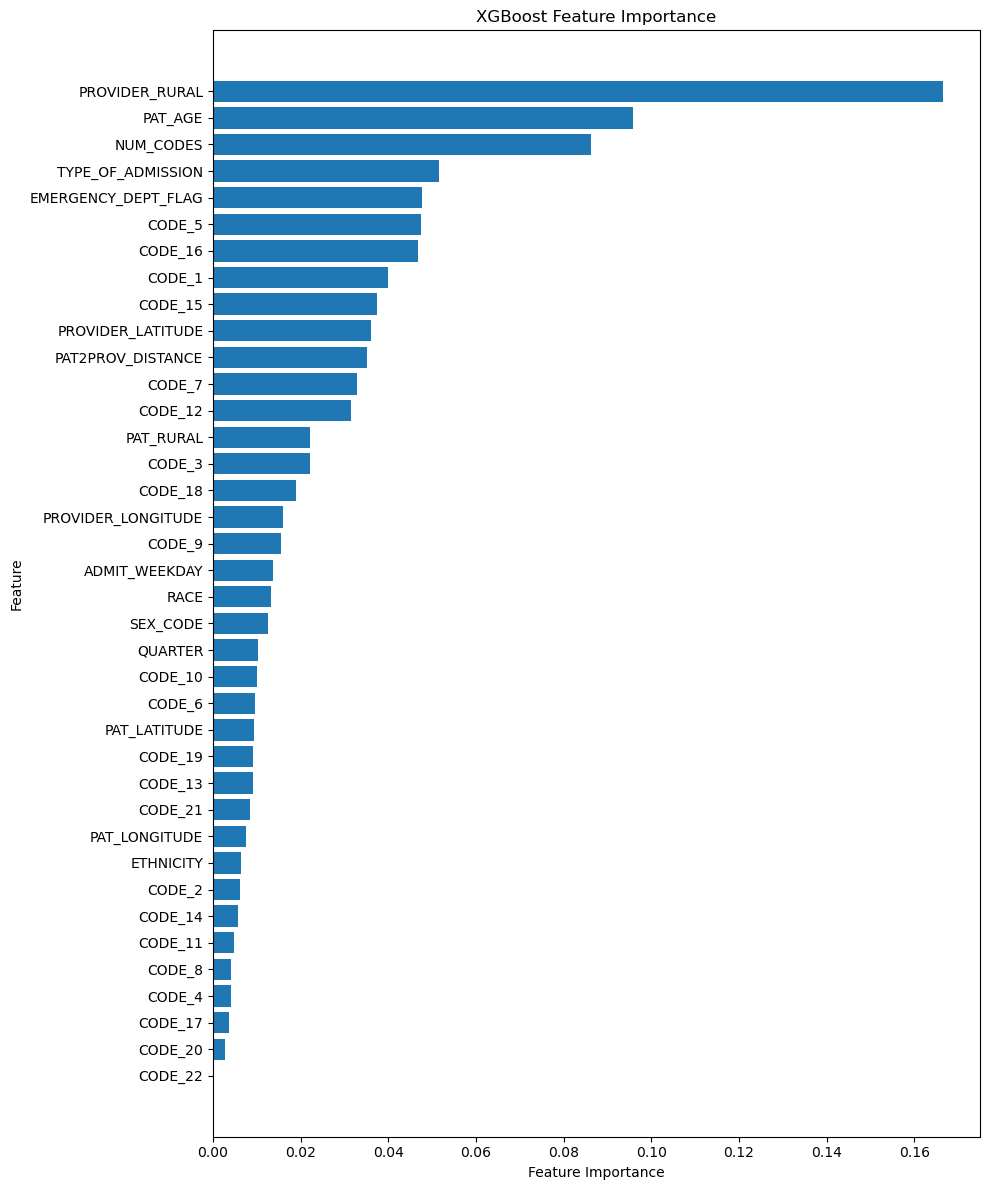

In [39]:
# Feature Importance for RMSE model
importance_df = pd.DataFrame({
    "Feature": X_train[features].columns,
    "Importance": full_rmse_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 12))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

# Largest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()